In [4]:
# Pour la manipulation de tableaux
import numpy as np

# Imports nécessaires pour construire un modèle CNN avec l'API fonctionnelle de Keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dropout 
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Conv2D 
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import f1_score, accuracy_score, classification_report

# Pour encoder les labels
from tensorflow.keras.utils import to_categorical

# Pour évaluer les performances 
from sklearn import metrics

# Pour visualiser les performances
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
%matplotlib inline



In [16]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')

[]

In [6]:
train_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/train_augmented/",                                 
    image_size=(299, 299),
    batch_size = 32*5,
    labels="inferred",
    seed = 42,
    color_mode='grayscale'
    
)


Found 33336 files belonging to 4 classes.


In [7]:
val_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/validation/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42,
    color_mode='grayscale'
)



Found 2083 files belonging to 4 classes.


In [8]:
test_ds = image_dataset_from_directory(
    directory="../../COVID-19_Radiography_Dataset_split/test/",                                 
    image_size=(299, 299),
    batch_size = 32,
    labels="inferred",
    seed = 42,
    color_mode='grayscale'
)

Found 2084 files belonging to 4 classes.


In [9]:
from tensorflow.keras.callbacks import Callback
from timeit import default_timer as timer

class TimingCallback(Callback):
    def __init__(self, logs={}):
        self.logs=[]
    def on_epoch_begin(self, epoch, logs={}):
        self.starttime = timer()
    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(timer()-self.starttime)

In [10]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

early_stopping = EarlyStopping(
                                patience=5, # Attendre 5 epochs avant application
                                min_delta=0.01, # si au bout de 5 epochs la fonction de perte ne varie pas de 1%, 
    # que ce soit à la hausse ou à la baisse, on arrête
                                verbose=1, # Afficher à quel epoch on s'arrête
                                mode='min',
                                monitor='val_loss')

reduce_learning_rate = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3, # si val_loss stagne sur 3 epochs consécutives selon la valeur min_delta
                                    min_delta=0.01,
                                    factor=0.1,  # On réduit le learning rate d'un facteur 0.1
                                    cooldown=4,  # On attend 4 epochs avant de réitérer 
                                    verbose=1)

time_callback = TimingCallback()

In [11]:
# Instanciation des couches
inputs = Input(shape=(299, 299, 1), name="Input")

normalization_layer=Rescaling(1./255)

first_layer = Conv2D(
    filters=32,
    kernel_size=(5, 5),
    padding='valid',
    activation='relu',
    name='conv_layer1',
)

second_layer = MaxPooling2D(
    pool_size=(2, 2),
    name='max_pooling_layer'
)

third_layer = Dropout(rate=0.2)

fourth_layer = Flatten()

fifth_layer = Dense(
    units=128,
    activation='relu',
    name='dense_hidden_layer'
)

output_layer = Dense(
    units=4,
    activation='softmax',
    name='output_layer'
)


In [12]:
# Utilisation des couches
x= normalization_layer(inputs)
x = first_layer(x)
x = second_layer(x)
x = third_layer(x)
x = fourth_layer(x)
x = fifth_layer(x)



# Création du modèle
outputs = output_layer(x)
model = Model(inputs=inputs, outputs=outputs)

In [17]:


model.compile(loss='sparse_categorical_crossentropy', # fonction de perte
              optimizer='adam',                # algorithme d'optimisation
              metrics=['accuracy'])            # métrique d'évaluation

model_history = model.fit(train_ds,
                          validation_data=val_ds,
                          epochs=50,
                          callbacks = [reduce_learning_rate,
                                       early_stopping,
                                       time_callback],
                          shuffle=False) 

Epoch 1/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 343s 2s/step - accuracy: 0.6959 - loss: 0.7583 - val_accuracy: 0.7681 - val_loss: 0.5863 - learning_rate: 0.0010
Epoch 2/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 337s 2s/step - accuracy: 0.8270 - loss: 0.4458 - val_accuracy: 0.7643 - val_loss: 0.6123 - learning_rate: 0.0010
Epoch 3/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9154 - loss: 0.2347 - val_accuracy: 0.7398 - val_loss: 0.7601 - learning_rate: 0.0010
Epoch 4/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9698 - loss: 0.0999
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00010000000474974513.
209/209 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - accuracy: 0.9698 - loss: 0.0999 - val_accuracy: 0.7484 - val_loss: 0.8950 - learning_rate: 0.0010
Epoch 5/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 346s 2s/step - accuracy: 0.9890 - loss: 0.0475 - val_accuracy: 0.7585 - val_loss: 0.9434 - learning_rate: 1.0000e-04
Epoch 6/50
209/209 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.9969 - loss: 

In [18]:
train_acc = model_history.history['accuracy']
val_acc = model_history.history['val_accuracy']

In [19]:
model_history.history['accuracy'].__sizeof__()

104

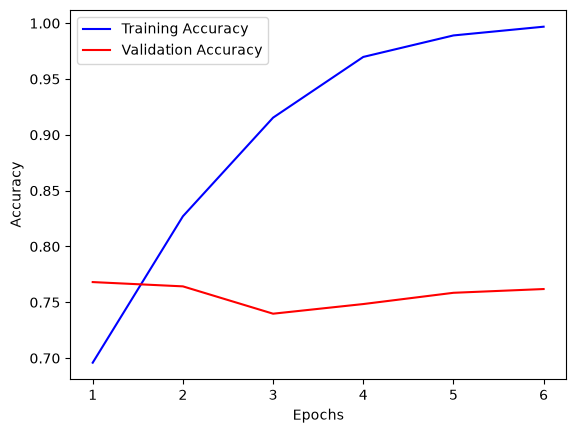

In [29]:
# Labels des axes
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Courbe de la précision sur l'échantillon d'entrainement
plt.plot(np.arange(1 , 7, 1),
         model_history.history['accuracy'],
         label='Training Accuracy',
         color='blue')

# Courbe de la précision sur l'échantillon de test
plt.plot(np.arange(1 , 7, 1),
         model_history.history['val_accuracy'], 
         label='Validation Accuracy',
         color='red')

# Affichage de la légende
plt.legend()

# Affichage de la figure
plt.show()

In [23]:
test_pred = model.predict(test_ds)

test_pred_class = test_pred.argmax(axis=1)
y_test_class = test_pred.argmax(axis=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       280
           1       1.00      1.00      1.00       604
           2       1.00      1.00      1.00      1070
           3       1.00      1.00      1.00       130

    accuracy                           1.00      2084
   macro avg       1.00      1.00      1.00      2084
weighted avg       1.00      1.00      1.00      2084



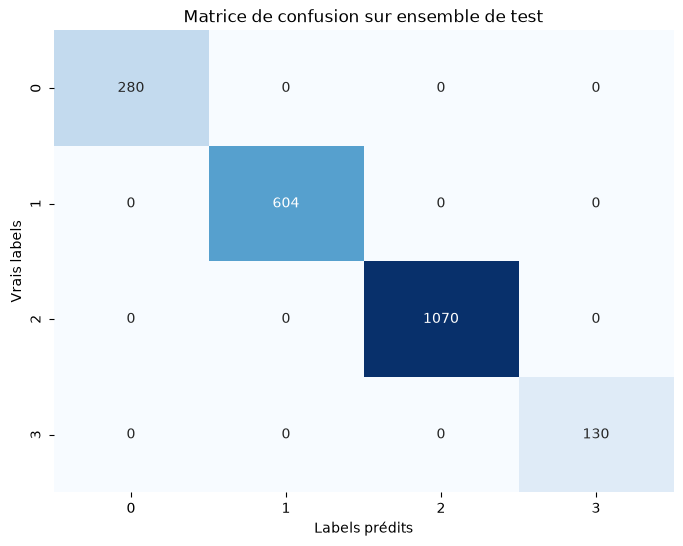

In [27]:
print(metrics.classification_report(y_test_class, test_pred_class))

# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_test_class, test_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de test")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()

In [25]:
val_pred = model.predict(val_ds)

val_pred_class = val_pred.argmax(axis=1)
y_val_class = val_pred.argmax(axis=1)

66/66 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step


              precision    recall  f1-score   support

           0       1.00      1.00      1.00       289
           1       1.00      1.00      1.00       599
           2       1.00      1.00      1.00      1067
           3       1.00      1.00      1.00       128

    accuracy                           1.00      2083
   macro avg       1.00      1.00      1.00      2083
weighted avg       1.00      1.00      1.00      2083



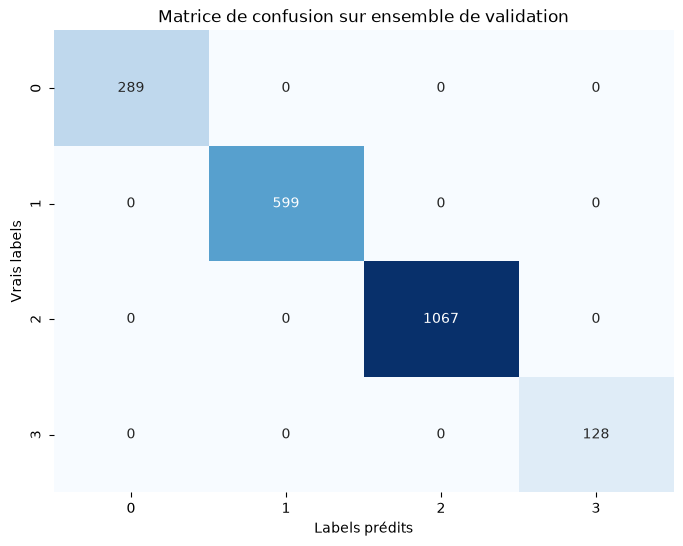

In [28]:
print(metrics.classification_report(y_val_class, val_pred_class))


# Calculer la matrice de confusion
cnf_matrix = metrics.confusion_matrix(y_val_class, val_pred_class)

# Tracer la heatmap de la matrice de confusion
plt.figure(figsize=(8, 6))

plt.title("Matrice de confusion sur ensemble de validation")
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt="")
plt.ylabel('Vrais labels')
plt.xlabel('Labels prédits')
plt.show()